# **Approval Model**

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)

## **Introduction**

Most credit approval models use a **PD cutoff**: approve if predicted default probability is below some threshold. This is intuitive but suboptimal — it ignores the rate the borrower is paying and the severity of the loss if they default. A high-rate loan with moderate PD may be more profitable than a low-rate loan with low PD.

This notebook defines an **EP-based approval rule**:

$$\text{Approve if } \text{EP} > \text{hurdle\_rate} \times \text{funded\_amnt}$$

where `hurdle_rate` is the minimum acceptable expected profit as a fraction of the funded amount. Setting `hurdle_rate = 0` means: approve any loan with positive expected profit. Setting it higher enforces a minimum return requirement.

The rule translates directly into a PD threshold, but one that **varies by borrower** — a higher-rate borrower can have a higher PD and still clear the hurdle. This is the key advantage over a fixed PD cutoff.

**What this notebook produces:**
1. Approval decision for each loan under a given hurdle rate
2. Sensitivity analysis across a range of hurdle rates
3. Comparison: EP-based approval vs. PD cutoff approval
4. Approved book characterization
5. `ApprovalModel` class — exported as `approval_model.pkl`

## **Load Data**

In [2]:
df = pd.read_parquet('ep_results.parquet')

print(f'Portfolio: {len(df):,} loans')
print(f'Columns: {list(df.columns)}')
df[['funded_amnt', 'int_rate', 'pd_score', 'el_ratio', 'ep', 'ep_ratio']].describe().round(4)

Portfolio: 1,345,310 loans
Columns: ['funded_amnt', 'int_rate', 'term', 'grade_label', 'purpose', 'issue_d_year', 'is_default', 'pd_score', 'lgd_hat', 'ead_ratio_hat', 'ead_hat', 'el', 'el_ratio', 'income', 'ep', 'ep_ratio', 'pd_breakeven', 'pd_margin']


,funded_amnt,int_rate,pd_score,el_ratio,ep,ep_ratio
count,"1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000","1,345,310.0000"
mean,"14,411.5566",13.2396,0.4474,0.2595,-609.8522,-0.0343
std,"8,713.1179",4.7687,0.1822,0.1305,"2,349.8082",0.1265
min,500.0000,5.3100,0.0347,0.0176,"-21,528.1404",-0.6138
25%,"8,000.0000",9.7500,0.3138,0.1614,"-1,274.7687",-0.1032
50%,"12,000.0000",12.7400,0.4473,0.2444,-96.1624,-0.0114
75%,"20,000.0000",15.9900,0.5760,0.3379,571.7183,0.0599
max,"40,000.0000",30.9900,0.9297,0.7072,"16,951.4796",0.4806


## **The Approval Rule**

### **From EP to an implicit PD threshold**

Setting EP = `hurdle_rate × funded_amnt` and solving for PD:

$$\text{EP} = (1 - \text{PD}) \cdot \text{Income} - \text{PD} \cdot \text{LGD} \cdot \text{EAD} = h \cdot F$$

$$\text{PD}^*(h) = \frac{\text{Income} - h \cdot F}{\text{Income} + \text{LGD} \cdot \text{EAD}}$$

This is the maximum PD a loan can carry to clear hurdle rate $h$. It depends on the loan's own rate, LGD, and EAD — so each borrower gets a personalised implicit threshold. The standard PD cutoff is the special case where everyone gets the same threshold regardless of rate.

In [3]:
# Hurdle rate parameter
# Fraction of funded_amnt that the loan must contribute in expected profit to be approved.
# 0.00 = approve any loan with positive EP
# 0.02 = approve only loans expected to return at least 2% of funded amount
HURDLE_RATE = 0.00

# Approval decision
df['approved_ep'] = (df['ep_ratio'] > HURDLE_RATE).astype(int)

# Implicit PD threshold per loan (the PD* that corresponds to the hurdle rate)
df['pd_threshold'] = (
    df['income'] - HURDLE_RATE * df['funded_amnt']
) / (
    df['income'] + df['lgd_hat'] * df['ead_hat'] + 1e-9
)  # income already corrected in ep_results.parquet
df['pd_threshold'] = df['pd_threshold'].clip(0, 1)

n_approved = df['approved_ep'].sum()
print(f'Hurdle rate          : {HURDLE_RATE:.2%}')
print(f'Loans approved       : {n_approved:,}  ({n_approved / len(df):.1%})')
print(f'Loans rejected       : {len(df) - n_approved:,}  ({1 - n_approved / len(df):.1%})')
print()
approved = df[df['approved_ep'] == 1]
print(f'Approved book — mean EP ratio : {approved["ep_ratio"].mean():.2%}')
print(f'Approved book — mean PD       : {approved["pd_score"].mean():.2%}')
print(f'Approved book — mean EL ratio : {approved["el_ratio"].mean():.2%}')
print(f'Approved book — total EP      : ${approved["ep"].sum():,.0f}')

Hurdle rate          : 0.00%
Loans approved       : 620,933  (46.2%)
Loans rejected       : 724,377  (53.8%)

Approved book — mean EP ratio : 6.90%
Approved book — mean PD       : 29.98%
Approved book — mean EL ratio : 16.11%
Approved book — total EP      : $617,210,282


## **Implicit PD Threshold by Rate**

The EP-based rule assigns a different maximum tolerable PD to each borrower based on their interest rate, predicted LGD and EAD. This cell shows how the implicit threshold varies across the rate spectrum — and how it compares to where actual borrowers sit.

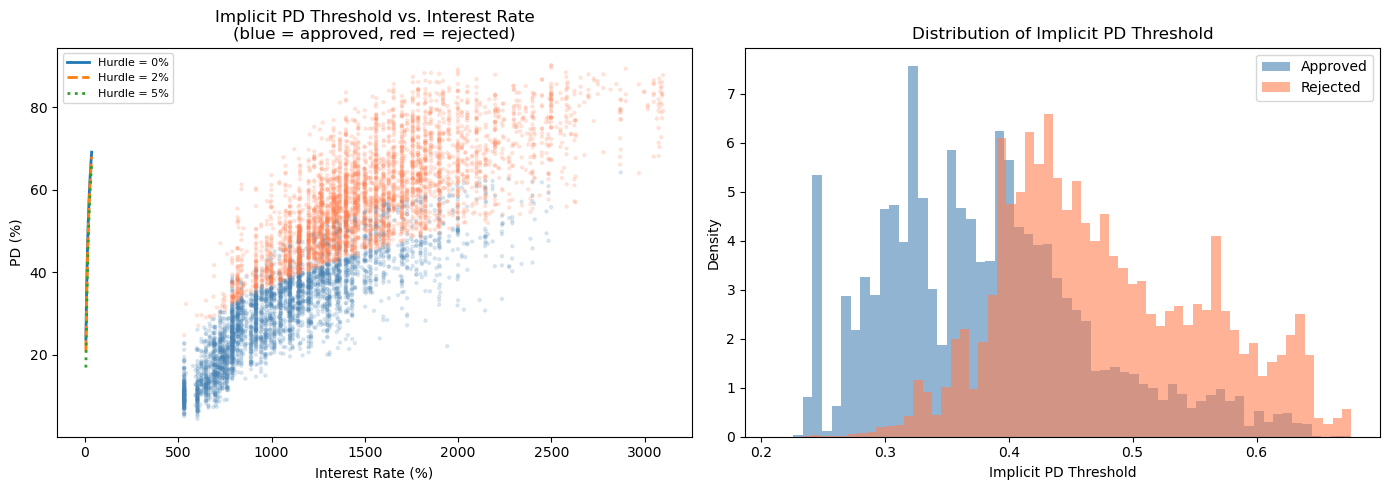

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Implicit threshold vs int_rate (using portfolio-mean LGD and EAD for the curve)
mean_lgd  = df['lgd_hat'].mean()
mean_ead  = df['ead_ratio_hat'].mean()
rate_range = np.linspace(0.05, 0.36, 300)
mean_term_years = df['term'].mean() / 12
income_range = rate_range * mean_term_years  # total income per unit, over loan life

for h, style, label in [
    (0.00, '-',  'Hurdle = 0%'),
    (0.02, '--', 'Hurdle = 2%'),
    (0.05, ':',  'Hurdle = 5%'),
]:
    pd_star = (income_range - h) / (income_range + mean_lgd * mean_ead + 1e-9)
    pd_star = np.clip(pd_star, 0, 1)
    axes[0].plot(rate_range * 100, pd_star * 100, linestyle=style, linewidth=2, label=label)

sample = df.sample(min(8000, len(df)), random_state=42)
axes[0].scatter(
    sample['int_rate'] * 100, sample['pd_score'] * 100,
    c=sample['approved_ep'].map({1: 'steelblue', 0: 'coral'}),
    alpha=0.15, s=5,
)
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('PD (%)')
axes[0].set_title('Implicit PD Threshold vs. Interest Rate\n(blue = approved, red = rejected)')
axes[0].legend(fontsize=8)

# Distribution of PD threshold across approved/rejected
axes[1].hist(df[df['approved_ep'] == 1]['pd_threshold'].clip(0, 1),
             bins=60, alpha=0.6, color='steelblue', label='Approved', density=True)
axes[1].hist(df[df['approved_ep'] == 0]['pd_threshold'].clip(0, 1),
             bins=60, alpha=0.6, color='coral',     label='Rejected', density=True)
axes[1].set_xlabel('Implicit PD Threshold')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Implicit PD Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

## **Hurdle Rate Sensitivity**

The hurdle rate is the main tuning parameter of the approval policy. Sweeping it from 0 to some maximum shows how the approval rate, portfolio EP, EL ratio, and observed default rate change. This is the calibration chart for setting the operational hurdle rate.

In [5]:
hurdles = np.linspace(0.0, 0.20, 200)
results = []

for h in hurdles:
    app = df[df['ep_ratio'] > h]
    if len(app) == 0:
        break
    results.append({
        'hurdle':          h,
        'approval_rate':   len(app) / len(df),
        'total_ep':        app['ep'].sum(),
        'mean_ep_ratio':   app['ep_ratio'].mean(),
        'mean_el_ratio':   app['el_ratio'].mean(),
        'mean_pd':         app['pd_score'].mean(),
        'obs_default_rate':app['is_default'].mean(),
        'pct_profitable':  (app['ep'] > 0).mean(),
    })

sens = pd.DataFrame(results)

# EP-maximising hurdle rate
best_h_idx = sens['total_ep'].idxmax()
best_h     = sens.loc[best_h_idx, 'hurdle']
print(f'EP-maximising hurdle rate : {best_h:.4f}  ({best_h:.2%})')
print(f'Approval rate at that point: {sens.loc[best_h_idx, "approval_rate"]:.1%}')
print(f'Total EP at that point     : ${sens.loc[best_h_idx, "total_ep"]:,.0f}')

EP-maximising hurdle rate : 0.0000  (0.00%)
Approval rate at that point: 46.2%
Total EP at that point     : $617,210,282


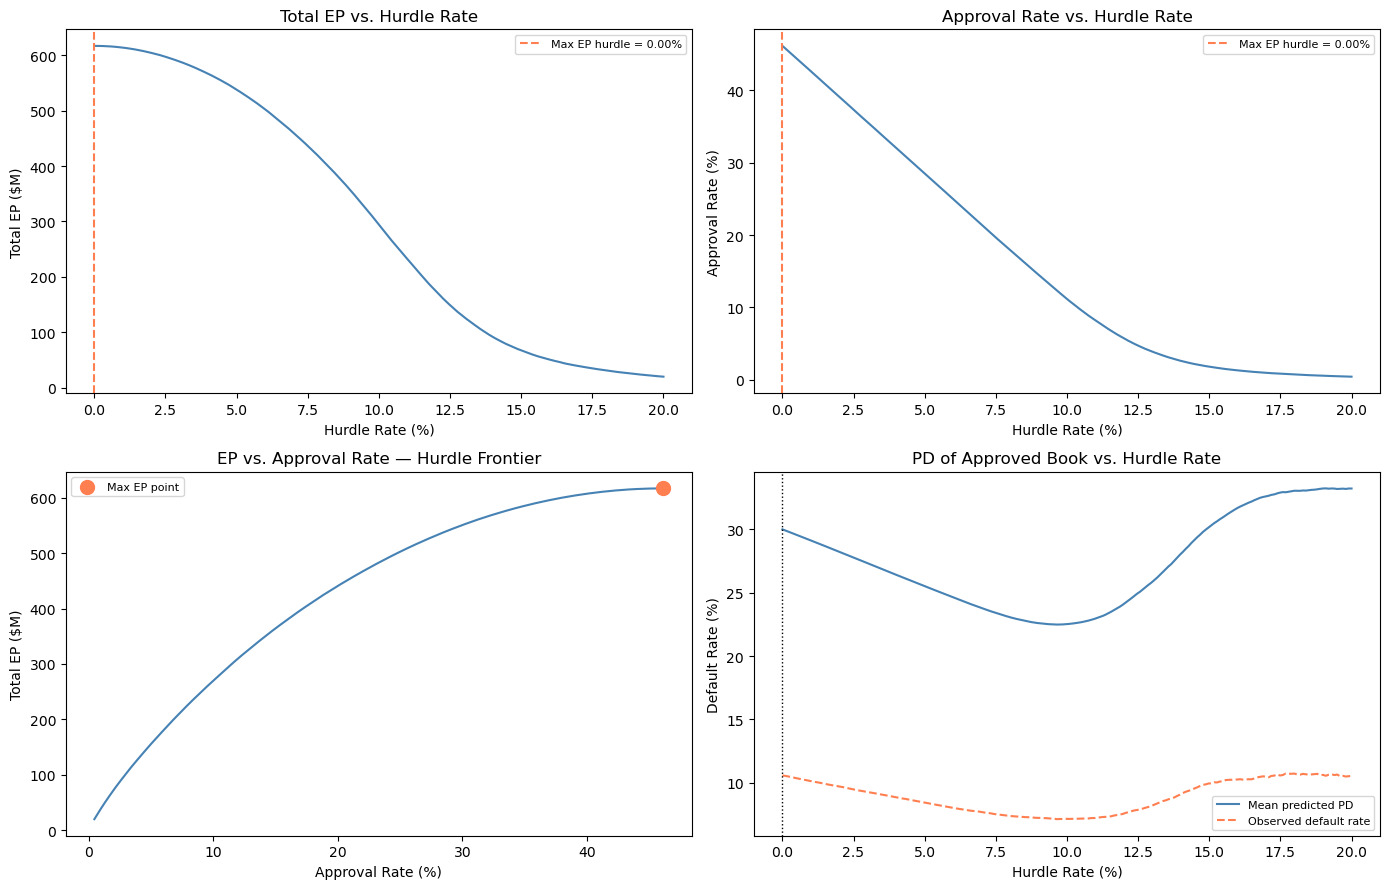

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

kw_vline = dict(color='coral', linestyle='--', linewidth=1.5, label=f'Max EP hurdle = {best_h:.2%}')

axes[0, 0].plot(sens['hurdle'] * 100, sens['total_ep'] / 1e6, color='steelblue')
axes[0, 0].axvline(best_h * 100, **kw_vline)
axes[0, 0].set_title('Total EP vs. Hurdle Rate')
axes[0, 0].set_xlabel('Hurdle Rate (%)')
axes[0, 0].set_ylabel('Total EP ($M)')
axes[0, 0].legend(fontsize=8)

axes[0, 1].plot(sens['hurdle'] * 100, sens['approval_rate'] * 100, color='steelblue')
axes[0, 1].axvline(best_h * 100, **kw_vline)
axes[0, 1].set_title('Approval Rate vs. Hurdle Rate')
axes[0, 1].set_xlabel('Hurdle Rate (%)')
axes[0, 1].set_ylabel('Approval Rate (%)')
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(sens['approval_rate'] * 100, sens['total_ep'] / 1e6, color='steelblue')
axes[1, 0].scatter(
    sens.loc[best_h_idx, 'approval_rate'] * 100,
    sens.loc[best_h_idx, 'total_ep'] / 1e6,
    color='coral', s=100, zorder=5, label='Max EP point'
)
axes[1, 0].set_title('EP vs. Approval Rate — Hurdle Frontier')
axes[1, 0].set_xlabel('Approval Rate (%)')
axes[1, 0].set_ylabel('Total EP ($M)')
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(sens['hurdle'] * 100, sens['mean_pd'] * 100,
                color='steelblue', label='Mean predicted PD')
axes[1, 1].plot(sens['hurdle'] * 100, sens['obs_default_rate'] * 100,
                color='coral', linestyle='--', label='Observed default rate')
axes[1, 1].axvline(best_h * 100, color='black', linestyle=':', linewidth=1)
axes[1, 1].set_title('PD of Approved Book vs. Hurdle Rate')
axes[1, 1].set_xlabel('Hurdle Rate (%)')
axes[1, 1].set_ylabel('Default Rate (%)')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## **EP-Based vs. PD Cutoff — Head-to-Head**

The key question is whether the EP-based rule actually outperforms a naive PD cutoff. I compare both strategies at the **same approval rate** — for every PD cutoff that produces a given approval rate, I find the EP hurdle that produces the same rate, and compare the resulting total EP and observed default rate on the approved book.

If the EP rule dominates: at the same approval rate, the EP rule should have higher total EP and/or lower EL ratio. This would justify the added complexity.

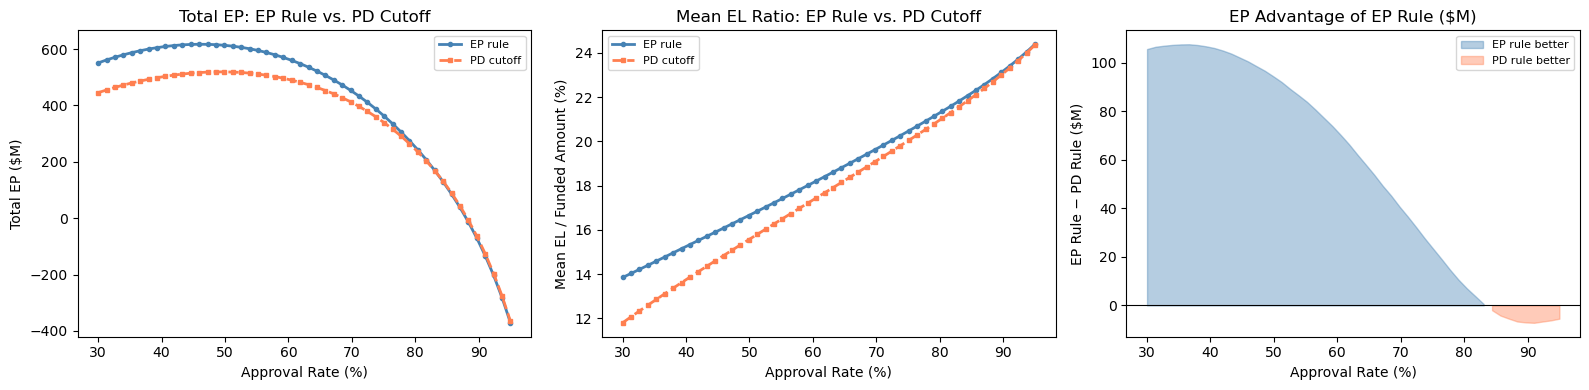

Mean EP advantage across all approval rates: $56.32M
EP rule wins at 82% of approval rate levels tested


In [7]:
# For a grid of approval rates, find the best PD cutoff and EP hurdle
target_rates = np.linspace(0.30, 0.95, 50)

comparison = []
for target in target_rates:
    # PD cutoff that achieves this approval rate
    pd_cutoff = np.quantile(df['pd_score'], target)
    app_pd  = df[df['pd_score'] < pd_cutoff]

    # EP hurdle that achieves the closest approval rate
    h_cutoff = np.quantile(df['ep_ratio'], 1 - target)
    app_ep  = df[df['ep_ratio'] > h_cutoff]

    if len(app_pd) == 0 or len(app_ep) == 0:
        continue

    comparison.append({
        'approval_rate':          target,
        'ep_rule_total_ep':       app_ep['ep'].sum(),
        'pd_rule_total_ep':       app_pd['ep'].sum(),
        'ep_rule_mean_el_ratio':  app_ep['el_ratio'].mean(),
        'pd_rule_mean_el_ratio':  app_pd['el_ratio'].mean(),
        'ep_rule_obs_default':    app_ep['is_default'].mean(),
        'pd_rule_obs_default':    app_pd['is_default'].mean(),
    })

cmp = pd.DataFrame(comparison)
cmp['ep_advantage_M'] = (cmp['ep_rule_total_ep'] - cmp['pd_rule_total_ep']) / 1e6

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(cmp['approval_rate'] * 100, cmp['ep_rule_total_ep'] / 1e6,
             'o-', color='steelblue', linewidth=2, label='EP rule', markersize=3)
axes[0].plot(cmp['approval_rate'] * 100, cmp['pd_rule_total_ep'] / 1e6,
             's--', color='coral', linewidth=2, label='PD cutoff', markersize=3)
axes[0].set_title('Total EP: EP Rule vs. PD Cutoff')
axes[0].set_xlabel('Approval Rate (%)')
axes[0].set_ylabel('Total EP ($M)')
axes[0].legend(fontsize=8)

axes[1].plot(cmp['approval_rate'] * 100, cmp['ep_rule_mean_el_ratio'] * 100,
             'o-', color='steelblue', linewidth=2, label='EP rule', markersize=3)
axes[1].plot(cmp['approval_rate'] * 100, cmp['pd_rule_mean_el_ratio'] * 100,
             's--', color='coral', linewidth=2, label='PD cutoff', markersize=3)
axes[1].set_title('Mean EL Ratio: EP Rule vs. PD Cutoff')
axes[1].set_xlabel('Approval Rate (%)')
axes[1].set_ylabel('Mean EL / Funded Amount (%)')
axes[1].legend(fontsize=8)

axes[2].fill_between(cmp['approval_rate'] * 100, cmp['ep_advantage_M'], 0,
                     where=cmp['ep_advantage_M'] >= 0, alpha=0.4, color='steelblue',
                     label='EP rule better')
axes[2].fill_between(cmp['approval_rate'] * 100, cmp['ep_advantage_M'], 0,
                     where=cmp['ep_advantage_M'] < 0, alpha=0.4, color='coral',
                     label='PD rule better')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('EP Advantage of EP Rule ($M)')
axes[2].set_xlabel('Approval Rate (%)')
axes[2].set_ylabel('EP Rule − PD Rule ($M)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Mean EP advantage across all approval rates: ${cmp["ep_advantage_M"].mean():.2f}M')
print(f'EP rule wins at {(cmp["ep_advantage_M"] > 0).mean():.0%} of approval rate levels tested')

## **Approved Book Characterization**

With the hurdle rate set to the EP-maximising value found in section 5, this section profiles the approved book — what it looks like across grades, terms, and purposes.

In [8]:
# Apply the EP-maximising hurdle rate
HURDLE_FINAL = best_h
df['approved_final'] = (df['ep_ratio'] > HURDLE_FINAL).astype(int)

approved = df[df['approved_final'] == 1].copy()
rejected = df[df['approved_final'] == 0].copy()

print(f'Hurdle rate (EP-maximising) : {HURDLE_FINAL:.2%}')
print(f'Approved loans             : {len(approved):,}  ({len(approved)/len(df):.1%})')
print(f'Rejected loans             : {len(rejected):,}  ({len(rejected)/len(df):.1%})')
print()
print('--- Approved book summary ---')
print(f'  Mean funded amount       : ${approved["funded_amnt"].mean():>10,.0f}')
print(f'  Mean int rate            : {approved["int_rate"].mean():>10.2f}%')
print(f'  Mean PD score            : {approved["pd_score"].mean():>10.2%}')
print(f'  Mean EP ratio            : {approved["ep_ratio"].mean():>10.2%}')
print(f'  Mean EL ratio            : {approved["el_ratio"].mean():>10.2%}')
print(f'  Observed default rate    : {approved["is_default"].mean():>10.2%}')

Hurdle rate (EP-maximising) : 0.00%
Approved loans             : 620,933  (46.2%)
Rejected loans             : 724,377  (53.8%)

--- Approved book summary ---
  Mean funded amount       : $    13,980
  Mean int rate            :      10.69%
  Mean PD score            :     29.98%
  Mean EP ratio            :      6.90%
  Mean EL ratio            :     16.11%
  Observed default rate    :     10.60%


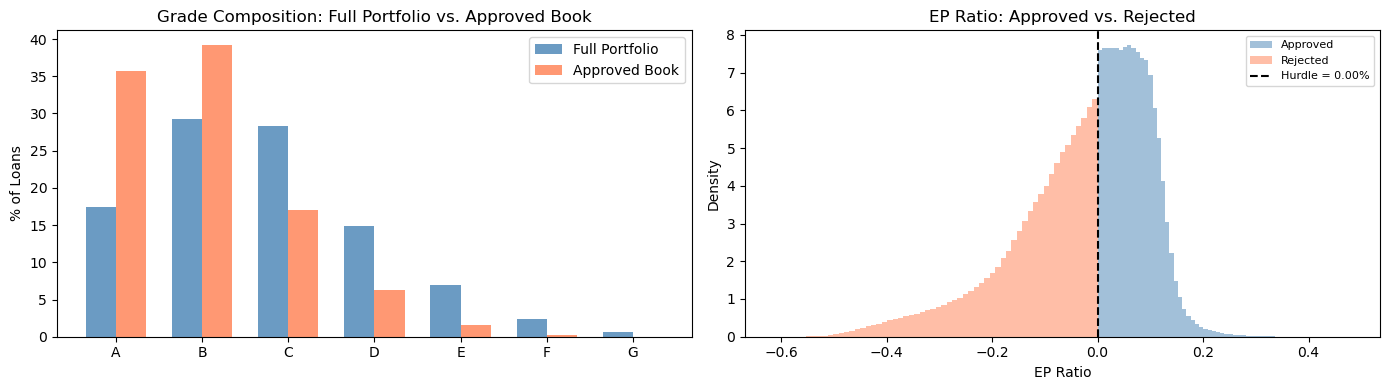

In [9]:
# Grade composition of approved vs full portfolio
grade_comp = pd.DataFrame({
    'Full Portfolio': df.groupby('grade_label', observed=False).size() / len(df),
    'Approved Book':  approved.groupby('grade_label', observed=False).size() / len(approved),
}).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = np.arange(len(grade_comp))
w = 0.35
axes[0].bar(x - w/2, grade_comp['Full Portfolio'] * 100, w, label='Full Portfolio', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, grade_comp['Approved Book']  * 100, w, label='Approved Book',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(grade_comp.index)
axes[0].set_title('Grade Composition: Full Portfolio vs. Approved Book')
axes[0].set_ylabel('% of Loans')
axes[0].legend()

# EP ratio distribution: approved vs rejected
axes[1].hist(approved['ep_ratio'], bins=60, alpha=0.5, color='steelblue',
             label='Approved', density=True)
axes[1].hist(rejected['ep_ratio'], bins=60, alpha=0.5, color='coral',
             label='Rejected', density=True)
axes[1].axvline(HURDLE_FINAL, color='black', linestyle='--', linewidth=1.5,
                label=f'Hurdle = {HURDLE_FINAL:.2%}')
axes[1].set_xlabel('EP Ratio')
axes[1].set_ylabel('Density')
axes[1].set_title('EP Ratio: Approved vs. Rejected')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## **ApprovalModel Export**

The `ApprovalModel` class takes raw model outputs (PD score, LGD prediction, EAD prediction, funded amount, int rate) and returns an approval decision. It is the only artifact consumed by the deployment layer.

Internally it computes EP and applies the hurdle rate. It also exposes `.ep()` and `.pd_threshold()` for inspection.

In [10]:
import joblib


class ApprovalModel:

    def __init__(self, hurdle_rate: float = 0.0):
        self.hurdle_rate = hurdle_rate

    # ------------------------------------------------------------------
    def ep(self,
           pd_score:    np.ndarray,
           lgd_hat:     np.ndarray,
           ead_hat:     np.ndarray,
           funded_amnt: np.ndarray,
           int_rate:    np.ndarray,
           term:        np.ndarray) -> np.ndarray:
     
        income = (int_rate / 100) * funded_amnt * (term / 12)
        return (1 - pd_score) * income - pd_score * lgd_hat * ead_hat

    def ep_ratio(self,
                 pd_score:    np.ndarray,
                 lgd_hat:     np.ndarray,
                 ead_hat:     np.ndarray,
                 funded_amnt: np.ndarray,
                 int_rate:    np.ndarray,
                 term:        np.ndarray) -> np.ndarray:
  
        return self.ep(pd_score, lgd_hat, ead_hat, funded_amnt, int_rate, term) / (funded_amnt + 1e-9)

    def pd_threshold(self,
                     funded_amnt: np.ndarray,
                     int_rate:    np.ndarray,
                     lgd_hat:     np.ndarray,
                     ead_hat:     np.ndarray,
                     term:        np.ndarray) -> np.ndarray:
  
        income = (int_rate / 100) * funded_amnt * (term / 12)
        h_abs  = self.hurdle_rate * funded_amnt
        return np.clip(
            (income - h_abs) / (income + lgd_hat * ead_hat + 1e-9),
            0, 1
        )

    def approve(self,
                pd_score:    np.ndarray,
                lgd_hat:     np.ndarray,
                ead_hat:     np.ndarray,
                funded_amnt: np.ndarray,
                int_rate:    np.ndarray,
                term:        np.ndarray) -> np.ndarray:
    
        ep_r = self.ep_ratio(pd_score, lgd_hat, ead_hat, funded_amnt, int_rate, term)
        return (ep_r > self.hurdle_rate).astype(int)

    def __repr__(self):
        return f'ApprovalModel(hurdle_rate={self.hurdle_rate:.4f})'

# Instantiate with EP-maximising hurdle rate
approval_model = ApprovalModel(hurdle_rate=HURDLE_FINAL)
print(approval_model)

# Smoke test on a few loans
test = df.head(5)
decisions = approval_model.approve(
    test['pd_score'].values,
    test['lgd_hat'].values,
    test['ead_hat'].values,
    test['funded_amnt'].values,
    test['int_rate'].values,
    test['term'].values,
)
print(f'\nSmoke test decisions: {decisions}')
print(f'EP ratios           : {approval_model.ep_ratio(test["pd_score"].values, test["lgd_hat"].values, test["ead_hat"].values, test["funded_amnt"].values, test["int_rate"].values, test["term"].values).round(4)}')
print(f'Implicit PD thresholds: {approval_model.pd_threshold(test["funded_amnt"].values, test["int_rate"].values, test["lgd_hat"].values, test["ead_hat"].values, test["term"].values).round(4)}')

# Export
joblib.dump(approval_model, 'approval_model.pkl')
print(f'\nExported: approval_model.pkl  (hurdle_rate = {HURDLE_FINAL:.4f})')

ApprovalModel(hurdle_rate=0.0000)

Smoke test decisions: [1 0 0 0 0]
EP ratios           : [ 0.0484 -0.0878 -0.068  -0.239  -0.128 ]
Implicit PD thresholds: [0.4342 0.4024 0.453  0.6219 0.4211]

Exported: approval_model.pkl  (hurdle_rate = 0.0000)
